In [1]:
import DTRGym
import gymnasium as gym
import numpy as np
import os
import sys
import pickle as pkl
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
import torch
import matplotlib.pyplot as plt
import argparse
import csv
from gymnasium.core import RewardWrapper
from scipy import stats
from flow_matching.solver import ODESolver
from torch import nn, Tensor
from flow_matching.utils import ModelWrapper
import pandas as pd
import time

/home/azureuser/miniconda/envs/dtr/lib/python3.10/site-packages/wandb/apis/public.py:3106: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import parse_version
/home/azureuser/miniconda/envs/dtr/lib/python3.10/site-packages/pkg_resources/__init__.py:3147: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  declare_namespace(pkg)
/home/azureuser/miniconda/envs/dtr/lib/python3.10/site-packages/pkg_resources/__init__.py:3147: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('lazr')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/la

# Cancer

In [16]:
sys.path.append('../NLOT')
AGENT_PATH = "policies/ppo_ghaffari_cancer_model__0.zip"
AGENT_NAME = "single_agent_eval"
ENV_NAME = 'GhaffariCancerEnv-continuous'
NUM_EVAL_EPISODES = 10
LAMBDA_VALUES = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
device = "cuda:0"

def print_results(results, name):
    mean = np.mean(results)
    std = np.std(results)
    ci = 1.96 * std / np.sqrt(len(results))
    print(f"{name}: {mean:.3f} ± {ci:.3f}")

In [90]:
# Activation class
class Swish(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x: Tensor) -> Tensor: 
        return torch.sigmoid(x) * x

# Model class
class MLP(nn.Module):
    def __init__(self, input_dim: int = 2, time_dim: int = 1, hidden_dim: int = 128, cond_dim: int = 1):
        super().__init__()
        
        self.input_dim = input_dim
        self.time_dim = time_dim
        self.hidden_dim = hidden_dim
        self.cond_dim = cond_dim

        self.main = nn.Sequential(
            nn.Linear(input_dim+time_dim+cond_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, input_dim),
            )
    

    def forward(self, x: Tensor, t: Tensor, cond: Tensor) -> Tensor:
        sz = x.size()
        x = x.reshape(-1, self.input_dim)
        t = t.reshape(-1, self.time_dim).float()
        cond = cond.reshape(-1, self.cond_dim).float()

        t = t.reshape(-1, 1).expand(x.shape[0], 1)
        h = torch.cat([x, t, cond], dim=1)
        output = self.main(h)
        
        return output.reshape(*sz)

class WrappedModel(ModelWrapper):
    def forward(self, x: torch.Tensor, t: torch.Tensor, cond: torch.Tensor, **extras):
        return self.model(x, t, cond)

In [242]:
class Swish(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x: Tensor) -> Tensor: 
        return torch.sigmoid(x) * x

# Model class with FiLM conditioning
class FiLMMLP(nn.Module):
    def __init__(self, input_dim: int = 2, time_dim: int = 1, hidden_dim: int = 128, cond_dim: int = 1):
        super().__init__()
        
        self.input_dim = input_dim
        self.time_dim = time_dim
        self.hidden_dim = hidden_dim
        self.cond_dim = cond_dim
        
        # Main network layers
        self.input_layer = nn.Linear(input_dim + time_dim, hidden_dim)
        self.hidden_layers = nn.ModuleList([
            nn.Linear(hidden_dim, hidden_dim) for _ in range(3)
        ])
        self.output_layer = nn.Linear(hidden_dim, input_dim)
        
        self.activation = Swish()
        
        # FiLM generator network
        # It will generate gammas and betas for the 4 layers (input + 3 hidden)
        num_film_layers = len(self.hidden_layers) + 1 
        self.film_generator = nn.Sequential(
            nn.Linear(cond_dim, hidden_dim),
            self.activation,
            nn.Linear(hidden_dim, num_film_layers * hidden_dim * 2) # *2 for gamma and beta
        )
        
    def forward(self, x: Tensor, t: Tensor, cond: Tensor) -> Tensor:
        sz = x.size()
        x = x.reshape(-1, self.input_dim)
        t = t.reshape(-1, self.time_dim).float()
        cond = cond.reshape(-1, self.cond_dim).float()

        # Expand time to match batch size
        t = t.reshape(-1, 1).expand(x.shape[0], 1)
        
        # Generate FiLM parameters from condition
        film_params = self.film_generator(cond)
        
        # Split FiLM params into gammas and betas for each layer
        num_film_layers = len(self.hidden_layers) + 1
        gammas = film_params[:, :num_film_layers * self.hidden_dim].reshape(-1, num_film_layers, self.hidden_dim)
        betas = film_params[:, num_film_layers * self.hidden_dim:].reshape(-1, num_film_layers, self.hidden_dim)

        # Main forward pass
        h = torch.cat([x, t], dim=1)
        
        # Input layer
        h = self.input_layer(h)
        h = gammas[:, 0, :] * h + betas[:, 0, :] # Apply FiLM
        h = self.activation(h)
        
        # Hidden layers
        for i, layer in enumerate(self.hidden_layers):
            h = layer(h)
            h = gammas[:, i + 1, :] * h + betas[:, i + 1, :] # Apply FiLM
            h = self.activation(h)
            
        # Output layer
        output = self.output_layer(h)
        
        return output.reshape(*sz)

In [92]:
class CustomRewardWrapper(RewardWrapper):
    def __init__(self, env, lambda_nk: float = 0.5):
        super().__init__(env)
        self.lambda_nk = lambda_nk
        self.init_obs = None

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self.init_obs = np.array(obs, copy=True)
        return obs, info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)

        if self.init_obs is not None:
            N_p  = obs[1]
            N_s  = obs[5]
            N_p0 = self.init_obs[1]
            N_s0 = self.init_obs[5]
            N  = max(np.e,  N_p  + N_s)
            N0 = max(np.e,  N_p0 + N_s0)
            logN, logN0 = np.log(N), np.log(N0)
            nk_penalty = -np.abs(logN / logN0 - 1)
            reward = reward + self.lambda_nk * nk_penalty

        return obs, reward, terminated, truncated, info

In [93]:
def flow_forward(action, obs, lambda_val, cfm_models):
    """
    Uses the trained CFM model to push actions forward to target lambda.

    cfm_models is a dict, with key as the time of the end point, and value as the CFM model.
    """
    time_points = list(cfm_models.keys())
    current_action = action.copy()
    t_low = 0
    step_size = 0.01

    if lambda_val <= 0:
        return action

    for k in range(len(time_points)):
        t_high = time_points[k]

        if t_low <= lambda_val <= t_high:
            cfm_model = list(cfm_models.values())[k]
            lambda_val_scaled = (lambda_val - t_low) / (t_high - t_low)
            solver = ODESolver(velocity_model=cfm_model)

            current_action = solver.sample(
                time_grid=torch.tensor([0, lambda_val_scaled], device='cuda:0'), 
                x_init=torch.tensor([current_action], device='cuda:0'), 
                cond=torch.tensor([obs], device='cuda:0'), 
                method='midpoint', 
                step_size=step_size, 
                return_intermediates=True
                )[-1]
            
            break
        cfm_model = list(cfm_models.values())[k]
        solver = ODESolver(velocity_model=cfm_model)

        current_action = solver.sample(
            time_grid=torch.tensor([0, 1.0], device='cuda:0'),
            x_init=torch.tensor([current_action], device='cuda:0'), 
            cond=torch.tensor([obs], device='cuda:0'), 
            method='midpoint', 
            step_size=step_size, 
            return_intermediates=True
            )[-1].cpu().numpy()

        t_low = t_high

    action_dim = action.shape[1] if len(action.shape) > 1 else action.shape[0]
    flowforward_action = current_action[:action_dim].reshape(action.shape)
    flowforward_action = np.array(flowforward_action.cpu(), dtype=np.float32)
    return flowforward_action

In [94]:
def calculate_nk_penalty(current_obs_vec, initial_obs_vec):
    current_obs = current_obs_vec[0]
    initial_obs = initial_obs_vec[0]

    N_p  = current_obs[1]
    N_s  = current_obs[5]
    N_p0 = initial_obs[1]
    N_s0 = initial_obs[5]

    N  = max(np.e,  N_p  + N_s)
    N0 = max(np.e,  N_p0 + N_s0)

    logN = np.log(N)
    logN0 = np.log(N0)

    penalty = -np.abs(logN / logN0 - 1)
    return penalty

In [95]:
def evaluate_lambda(model, lambda_val, workspace):
    """Evaluate the agent with a specific lambda pushforward value."""
    def make_env():
        env = gym.make(ENV_NAME)
        env = CustomRewardWrapper(env, lambda_nk=lambda_val * 10)
        return env
    
    env = make_vec_env(make_env, n_envs=1)
    
    overall_average_penalties = []
    episode_rewards = []
    
    #print(f'\n--- Evaluating agent {AGENT_NAME} for NK penalty with lambda = {lambda_val} ---')

    for episode_num in range(NUM_EVAL_EPISODES):
        initial_obs_for_episode = env.reset()
        obs = initial_obs_for_episode
        done = False
        penalties_this_episode = []
        episode_reward = 0
        episode_steps = 0
        
        #print(f"Starting Episode {episode_num + 1}/{NUM_EVAL_EPISODES}")

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            modified_action = flow_forward(action, obs, lambda_val, workspace)
            next_obs, reward, done_array, info = env.step(modified_action)
            penalty = calculate_nk_penalty(next_obs, initial_obs_for_episode)
            penalties_this_episode.append(penalty)
            episode_reward += reward[0] 
            obs = next_obs
            done = done_array[0]
            episode_steps += 1
        
        avg_penalty_for_this_episode = np.mean(penalties_this_episode)
        overall_average_penalties.append(avg_penalty_for_this_episode)
        episode_rewards.append(episode_reward)
        #print(f"Episode {episode_num + 1}: Average NK Penalty = {avg_penalty_for_this_episode:.4f}, Steps = {episode_steps}")

    env.close()
    final_avg_nk_penalty = np.mean(overall_average_penalties)
    std_dev_nk_penalty = np.std(overall_average_penalties)
    final_avg_reward = np.mean(episode_rewards) 
    #print(f"\n--- Summary for Lambda = {lambda_val} ---")
    #print(f"Overall Average NK Penalty across {NUM_EVAL_EPISODES} episodes = {final_avg_nk_penalty:.4f}")
    #print(f"Standard Deviation of Per-Episode Average NK Penalties = {std_dev_nk_penalty:.4f}")
    #print(f"Overall Average Reward across {NUM_EVAL_EPISODES} episodes = {final_avg_reward:.4f}")

    return final_avg_nk_penalty, std_dev_nk_penalty, final_avg_reward

In [96]:
model = PPO.load(AGENT_PATH)

/home/azureuser/miniconda/envs/dtr/lib/python3.10/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


In [97]:
cfm_rewards = []
cfm_penalties = []

for i in range(5):
    print(f"Iteration {i+1} of 5")

    flow_0 = MLP(input_dim=2, time_dim=1, cond_dim=7, hidden_dim=128).to(device) 
    wrapped_flow_0 = WrappedModel(flow_0)
    flow_0_weights = torch.load(f'../rebuttal_baselines/cfm_cancer_model_0_{i}.pt')
    wrapped_flow_0.load_state_dict(flow_0_weights)

    flow_1 = MLP(input_dim=2, time_dim=1, cond_dim=7, hidden_dim=128).to(device)
    wrapped_flow_1 = WrappedModel(flow_1)
    flow_1_weights = torch.load(f'../rebuttal_baselines/cfm_cancer_model_1_{i}.pt')
    wrapped_flow_1.load_state_dict(flow_1_weights)

    flow_models={0.5: wrapped_flow_0, 1.0: wrapped_flow_1}

    model_rewards = []
    model_penalties = []
    for lambda_val in LAMBDA_VALUES:
        print(f"Evaluating lambda value: {lambda_val}")
        eval = evaluate_lambda(model, lambda_val, flow_models)
        model_penalties.append(eval[0])
        model_rewards.append(eval[2])

    print(np.mean(model_rewards))
    cfm_rewards.append(model_rewards)
    cfm_penalties.append(model_penalties)

Iteration 1 of 5
Evaluating lambda value: 0.0


/home/azureuser/miniconda/envs/dtr/lib/python3.10/site-packages/gymnasium/spaces/box.py:130: UserWarning: WARN: Box bound precision lowered by casting to float32
  gym.logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Evaluating lambda value: 0.1


/home/azureuser/miniconda/envs/dtr/lib/python3.10/site-packages/gymnasium/spaces/box.py:130: UserWarning: WARN: Box bound precision lowered by casting to float32
  gym.logger.warn(f"Box bound precision lowered by casting to {self.dtype}")
/home/azureuser/miniconda/envs/dtr/lib/python3.10/site-packages/stable_baselines3/common/vec_env/base_vec_env.py:78: UserWarning: The `render_mode` attribute is not defined in your environment. It will be set to None.
  warnings.warn("The `render_mode` attribute is not defined in your environment. It will be set to None.")


Evaluating lambda value: 0.2
Evaluating lambda value: 0.3
Evaluating lambda value: 0.4
Evaluating lambda value: 0.5
Evaluating lambda value: 0.6
Evaluating lambda value: 0.7
Evaluating lambda value: 0.8
Evaluating lambda value: 0.9
Evaluating lambda value: 1.0
46.16934458992698
Iteration 2 of 5
Evaluating lambda value: 0.0
Evaluating lambda value: 0.1
Evaluating lambda value: 0.2
Evaluating lambda value: 0.3
Evaluating lambda value: 0.4
Evaluating lambda value: 0.5
Evaluating lambda value: 0.6
Evaluating lambda value: 0.7
Evaluating lambda value: 0.8
Evaluating lambda value: 0.9
Evaluating lambda value: 1.0
72.16739835305647
Iteration 3 of 5
Evaluating lambda value: 0.0
Evaluating lambda value: 0.1
Evaluating lambda value: 0.2
Evaluating lambda value: 0.3
Evaluating lambda value: 0.4
Evaluating lambda value: 0.5
Evaluating lambda value: 0.6
Evaluating lambda value: 0.7
Evaluating lambda value: 0.8
Evaluating lambda value: 0.9
Evaluating lambda value: 1.0
-21.77727491313761
Iteration 4 

In [113]:
print_results([np.mean(i) for i in cfm_rewards], "CFM Rewards")

CFM Rewards: 23.444 ± 28.494


In [101]:
print([np.mean(i) for i in cfm_rewards])

[46.16934458992698, 72.16739835305647, -21.77727491313761, 11.815696955810893, 8.84704955816269]


In [107]:
print(np.mean([np.mean(i) for i in cfm_rewards]))
print(np.std([np.mean(i) for i in cfm_rewards]))

23.444442908763886
32.50742355671771


In [99]:
true = pd.read_csv('nk_penalty_plots/nk_penalty_data.csv')

In [100]:
plt.plot(LAMBDA_VALUES, [-i for i in cfm_penalties], marker='o')
plt.plot(LAMBDA_VALUES, [-i for i in true['Average Penalty']], marker='x')

TypeError: bad operand type for unary -: 'list'

# Naive eval

In [2]:
# Activation class
class Swish(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x: Tensor) -> Tensor: 
        return torch.sigmoid(x) * x

# Model class
class MLP(nn.Module):
    def __init__(self, input_dim: int = 2, time_dim: int = 1, hidden_dim: int = 128, cond_dim: int = 7):
        super().__init__()
        
        self.input_dim = input_dim
        self.time_dim = time_dim
        self.hidden_dim = hidden_dim
        self.cond_dim = cond_dim

        self.main = nn.Sequential(
            nn.Linear(input_dim+time_dim+cond_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, input_dim),
            )
    

    def forward(self, x: Tensor, t: Tensor, cond: Tensor) -> Tensor:
        sz = x.size()
        x = x.reshape(-1, self.input_dim)
        t = t.reshape(-1, self.time_dim).float()
        cond = cond.reshape(-1, self.cond_dim).float()

        t = t.reshape(-1, 1).expand(x.shape[0], 1)
        h = torch.cat([x, t, cond], dim=1)
        output = self.main(h)
        
        return output.reshape(*sz)

In [3]:
def naive_forward(action, obs, lambda_val, naive_model):
    """
    Uses the trained naive model to push actions forward to target lambda, where naive model can take in any lamda for a given action, obs pair.
    """
    if lambda_val <= 0:
        return action
    naive_action = naive_model(torch.tensor(action, device=device), torch.tensor(lambda_val, device=device), torch.tensor(obs, device=device)).cpu().detach().numpy()

    #clip to range [0,10] for first entry and [0,8] for second
    naive_action[0][0] = np.clip(naive_action[0][0], 0, 10)
    naive_action[0][1] = np.clip(naive_action[0][1], 0, 8)
    return naive_action

In [4]:
def evaluate_lambda(model, lambda_val, naive_model):
    """Evaluate the agent with a specific lambda pushforward value."""
    def make_env():
        env = gym.make(ENV_NAME)
        env = CustomRewardWrapper(env, lambda_nk=lambda_val * 10)
        return env
    
    env = make_vec_env(make_env, n_envs=1)
    
    overall_average_penalties = []
    episode_rewards = []
    
    #print(f'\n--- Evaluating agent {AGENT_NAME} for NK penalty with lambda = {lambda_val} ---')

    for episode_num in range(NUM_EVAL_EPISODES):
        initial_obs_for_episode = env.reset()
        obs = initial_obs_for_episode
        done = False
        penalties_this_episode = []
        episode_reward = 0
        episode_steps = 0
        
        #print(f"Starting Episode {episode_num + 1}/{NUM_EVAL_EPISODES}")

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            modified_action = naive_forward(action, obs, lambda_val, naive_model)
            next_obs, reward, done_array, info = env.step(modified_action)
            penalty = calculate_nk_penalty(next_obs, initial_obs_for_episode)
            penalties_this_episode.append(penalty)
            episode_reward += reward[0] 
            obs = next_obs
            done = done_array[0]
            episode_steps += 1
        
        avg_penalty_for_this_episode = np.mean(penalties_this_episode)
        overall_average_penalties.append(avg_penalty_for_this_episode)
        episode_rewards.append(episode_reward)
        #print(f"Episode {episode_num + 1}: Average NK Penalty = {avg_penalty_for_this_episode:.4f}, Steps = {episode_steps}")

    env.close()
    final_avg_nk_penalty = np.mean(overall_average_penalties)
    std_dev_nk_penalty = np.std(overall_average_penalties)
    final_avg_reward = np.mean(episode_rewards) 
    #print(f"\n--- Summary for Lambda = {lambda_val} ---")
    #print(f"Overall Average NK Penalty across {NUM_EVAL_EPISODES} episodes = {final_avg_nk_penalty:.4f}")
    #print(f"Standard Deviation of Per-Episode Average NK Penalties = {std_dev_nk_penalty:.4f}")
    #print(f"Overall Average Reward across {NUM_EVAL_EPISODES} episodes = {final_avg_reward:.4f}")

    return final_avg_nk_penalty, std_dev_nk_penalty, final_avg_reward

In [105]:
naive_rewards = []
naive_penalties = []

for i in range(5):
    print(f"Loading naive model {i} weights...")
    naive_model = MLP(
        input_dim=2,     # First 2 entries from timepoint 0
        time_dim=1,      # Timepoint (0, 5, or 10)
        hidden_dim=128,  # Hidden layer size
        cond_dim=7       # Remaining 7 entries from timepoint 0
    ).to(device)
    #load model
    naive_model_weights = torch.load(f'../rebuttal_baselines/naive_model_{i}.pt')
    naive_model.load_state_dict(naive_model_weights)

    model_pens = []
    model_rewards = []
    for lambda_val in LAMBDA_VALUES:
        print(f"Evaluating lambda value: {lambda_val}")
        eval = evaluate_lambda(model, lambda_val, naive_model)
        model_pens.append(eval[0])
        model_rewards.append(eval[2])

    print(np.mean(model_rewards))
    naive_rewards.append(model_rewards)
    naive_penalties.append(model_pens)

Loading naive model 0 weights...
Evaluating lambda value: 0.0


/home/azureuser/miniconda/envs/dtr/lib/python3.10/site-packages/gymnasium/spaces/box.py:130: UserWarning: WARN: Box bound precision lowered by casting to float32
  gym.logger.warn(f"Box bound precision lowered by casting to {self.dtype}")
/home/azureuser/miniconda/envs/dtr/lib/python3.10/site-packages/stable_baselines3/common/vec_env/base_vec_env.py:78: UserWarning: The `render_mode` attribute is not defined in your environment. It will be set to None.
  warnings.warn("The `render_mode` attribute is not defined in your environment. It will be set to None.")


Evaluating lambda value: 0.1
Evaluating lambda value: 0.2
Evaluating lambda value: 0.3
Evaluating lambda value: 0.4
Evaluating lambda value: 0.5
Evaluating lambda value: 0.6
Evaluating lambda value: 0.7
Evaluating lambda value: 0.8
Evaluating lambda value: 0.9
Evaluating lambda value: 1.0
-44.26456975828518
Loading naive model 1 weights...
Evaluating lambda value: 0.0
Evaluating lambda value: 0.1
Evaluating lambda value: 0.2
Evaluating lambda value: 0.3
Evaluating lambda value: 0.4
Evaluating lambda value: 0.5
Evaluating lambda value: 0.6
Evaluating lambda value: 0.7
Evaluating lambda value: 0.8
Evaluating lambda value: 0.9
Evaluating lambda value: 1.0
3.41673333482309
Loading naive model 2 weights...
Evaluating lambda value: 0.0
Evaluating lambda value: 0.1
Evaluating lambda value: 0.2
Evaluating lambda value: 0.3
Evaluating lambda value: 0.4
Evaluating lambda value: 0.5
Evaluating lambda value: 0.6
Evaluating lambda value: 0.7
Evaluating lambda value: 0.8
Evaluating lambda value: 0.9

In [106]:
[np.mean(i) for i in naive_rewards]

[-44.26456975828518,
 3.41673333482309,
 -11.315400278026404,
 9.974387534098193,
 21.881756478006192]

In [112]:
np.mean([np.mean(i) for i in naive_rewards])

-4.06141853787682

In [111]:
np.std([np.mean(i) for i in naive_rewards])

22.781082312144164

In [114]:
print_results([-44.26456975828518,
 3.41673333482309,
 -11.315400278026404,
 9.974387534098193,
 21.881756478006192], "Naive Rewards")

Naive Rewards: -4.061 ± 19.968


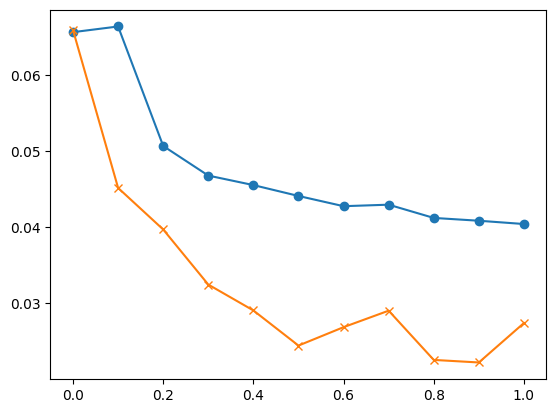

In [113]:
plt.plot(LAMBDA_VALUES, [-i for i in model_pens], marker='o')
true = pd.read_csv('nk_penalty_plots/nk_penalty_data.csv')
plt.plot(LAMBDA_VALUES, [-i for i in true['Average Penalty']], marker='x')

# Reacher

In [5]:
AGENT_PATH = "ppo_reacher_weight_1.zip"
VEC_ENV_FILE = "vec_normalize_reacher_weight_1.pkl"
AGENT_NAME = "single_agent_eval"
ENV_NAME = 'Reacher-v4'
NUM_EVAL_EPISODES = 10
LAMBDA_VALUES = [1,2,3,4,5]
device = "cuda:0"

In [6]:
import gymnasium as gym
import numpy as np
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
import matplotlib.pyplot as plt

class ReacherRewardWrapper(gym.Wrapper):
    def __init__(self, env, control_cost_weight=1.0):
        super().__init__(env)
        self.control_cost_weight = control_cost_weight

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        reward_dist = info['reward_dist']
        reward_ctrl = info['reward_ctrl']
        new_reward = reward_dist + self.control_cost_weight * reward_ctrl
        return obs, new_reward, terminated, truncated, info

In [7]:
# Activation class
class Swish(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x: Tensor) -> Tensor: 
        return torch.sigmoid(x) * x

# Model class
class MLP(nn.Module):
    def __init__(self, input_dim: int = 2, time_dim: int = 1, hidden_dim: int = 128, cond_dim: int = 1):
        super().__init__()
        
        self.input_dim = input_dim
        self.time_dim = time_dim
        self.hidden_dim = hidden_dim
        self.cond_dim = cond_dim

        self.main = nn.Sequential(
            nn.Linear(input_dim+time_dim+cond_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, input_dim),
            )
    

    def forward(self, x: Tensor, t: Tensor, cond: Tensor) -> Tensor:
        sz = x.size()
        x = x.reshape(-1, self.input_dim)
        t = t.reshape(-1, self.time_dim).float()
        cond = cond.reshape(-1, self.cond_dim).float()

        t = t.reshape(-1, 1).expand(x.shape[0], 1)
        h = torch.cat([x, t, cond], dim=1)
        output = self.main(h)
        
        return output.reshape(*sz)

class WrappedModel(ModelWrapper):
    def forward(self, x: torch.Tensor, t: torch.Tensor, cond: torch.Tensor, **extras):
        return self.model(x, t, cond)

In [8]:
def evaluate_lambda(model, vec_env_file, lambda_val, pushforward, pushforward_model=None):
    """Evaluate the agent with a specific lambda and pushforward"""
    def make_reacher_env():
        env = gym.make("Reacher-v4")
        env = ReacherRewardWrapper(env, control_cost_weight=lambda_val)
        return env

    env = VecNormalize.load(vec_env_file, DummyVecEnv([make_reacher_env]))
    env.training = False
    overall_average_penalties = []
    episode_rewards = []
    actions = []
    modified_actions = []
    
    for episode_num in range(NUM_EVAL_EPISODES):
        initial_obs_for_episode = env.reset()
        obs = initial_obs_for_episode
        done = False
        penalties_this_episode = []
        episode_reward = 0
        episode_steps = 0

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            modified_action = pushforward(action, obs, lambda_val, pushforward_model)
            actions.append(action)
            modified_actions.append(modified_action)
            next_obs, reward, done_array, info = env.step(modified_action)
            penalty = info[0]['reward_ctrl']
            penalties_this_episode.append(penalty)
            episode_reward += reward[0] 
            obs = next_obs
            done = done_array[0]
            episode_steps += 1
        
        avg_penalty_for_this_episode = np.mean(penalties_this_episode)
        overall_average_penalties.append(avg_penalty_for_this_episode)
        episode_rewards.append(episode_reward)

    env.close()
    final_avg_nk_penalty = np.mean(overall_average_penalties)
    std_dev_nk_penalty = np.std(overall_average_penalties)
    final_avg_reward = np.mean(episode_rewards) 
    return final_avg_nk_penalty, std_dev_nk_penalty, final_avg_reward

In [9]:
ppo_model = PPO.load(AGENT_PATH)

/home/azureuser/miniconda/envs/dtr/lib/python3.10/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


In [10]:
def null_pushforward(action, obs, lambda_val, pushforward_model=None):
    """
    A null pushforward function that returns the action unchanged.
    This is used when no pushforward is needed.
    """
    return action

In [11]:
def naive_pushforward(action, obs, lambda_val, pushforward_model):
    """
    Uses the trained naive model to push actions forward to target lambda, where naive model can take in any lamda for a given action, obs pair.
    """
    if lambda_val <= 1:
        return action
    naive_action = pushforward_model(torch.tensor(action, device=device), 
                                     torch.tensor(lambda_val, device=device), 
                                     torch.tensor(obs, device=device)).cpu().detach().numpy()

    return naive_action

In [12]:
def flow_pushforward(action, obs, lambda_val, pushforward_model):
    """
    Uses the trained CFM model to push actions forward to target lambda.
    """
    # scale lambda_val into [0,1], where min is 1 and max is 5
    time_point = (lambda_val - 1) / (5 - 1)
    if time_point <= 0:
        return action

    step_size = 0.05
    solver = ODESolver(velocity_model=pushforward_model)
    modified_action = solver.sample(
        time_grid=torch.tensor([0, time_point], device=device), 
        x_init=torch.tensor([action], device=device), 
        cond=torch.tensor([obs], device=device), 
        method='midpoint', 
        step_size=step_size, 
        return_intermediates=True
    )[-1][0].cpu().numpy()

    #print(action, modified_action)
    return modified_action

<All keys matched successfully>

<All keys matched successfully>

In [41]:
AGENT_PATH = f"ppo_reacher_weight_1.zip"
VEC_ENV_FILE = f"vec_normalize_reacher_weight_1.pkl"
ppo_model = PPO.load(AGENT_PATH)

pens_naive = []
rewards_naive = []

for j in range(5):
    print(f"Loading naive model {j} weights...")
    pens_naive_j = []
    rewards_naive_j = []
    naive_model = MLP(input_dim=2, time_dim=1, hidden_dim=128, cond_dim=11).to(device)
    naive_model_weights = torch.load(f'../rebuttal_baselines/naive_reacher_model_{j}.pt')
    naive_model.load_state_dict(naive_model_weights)

    for i in range(1,6):
        #VEC_ENV_FILE = f"vec_normalize_reacher_weight_{i}.pkl"
        eval = evaluate_lambda(ppo_model, VEC_ENV_FILE, i, naive_pushforward, naive_model)
        rew = eval[2]
        pen = eval[0]
        rewards_naive_j.append(rew)
        pens_naive_j.append(pen)
    pens_naive.append(pens_naive_j)
    rewards_naive.append(rewards_naive_j)
    print(np.mean(rewards_naive_j))

Loading naive model 0 weights...


-5.22584178366058
Loading naive model 1 weights...
-5.755754165323451
Loading naive model 2 weights...
-5.658318274556659
Loading naive model 3 weights...
-5.822402396907564
Loading naive model 4 weights...
-6.073721944962163


In [42]:
print_results([np.mean(i) for i in rewards_naive], "Naive Rewards")

Naive Rewards: -5.707 ± 0.243


In [209]:
np.mean(rewards_naive)

-5.791758815992159

In [39]:
AGENT_PATH = f"ppo_reacher_weight_1.zip"
VEC_ENV_FILE = f"vec_normalize_reacher_weight_1.pkl"
ppo_model = PPO.load(AGENT_PATH)

pens_flow = []
rewards_flow = []

for j in range(5):
    print(f"Loading CFM model {j} weights...")
    pens_flow_j = []
    rewards_flow_j = []
    cfm_model = MLP(input_dim=2, time_dim=1, cond_dim=11, hidden_dim=128).to(device) 
    cfm_model = WrappedModel(cfm_model)
    cfm_weights = torch.load(f'../rebuttal_baselines/cfm_reacher_model_{j}.pt')
    cfm_model.load_state_dict(cfm_weights)

    for i in range(1,6):
        #VEC_ENV_FILE = f"vec_normalize_reacher_weight_{i}.pkl"
        eval = evaluate_lambda(ppo_model, VEC_ENV_FILE, i, flow_pushforward, cfm_model)
        pen = eval[0]
        rew = eval[2]
        pens_flow_j.append(pen)
        rewards_flow_j.append(rew)
    pens_flow.append(pens_flow_j)
    rewards_flow.append(rewards_flow_j)
    print(np.mean(rewards_flow_j))

/home/azureuser/miniconda/envs/dtr/lib/python3.10/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(
/home/azureuser/miniconda/envs/dtr/lib/python3.10/site-packages/stable_baselines3/common/vec_env/base_vec_env.py:78: UserWarning: The `render_mode` attribute is not defined in your environment. It will be set to None.
  warnings.warn("The `render_mode` attribute is not defined in your environment. It will be set to None.")


Loading CFM model 0 weights...
-5.786385502950289
Loading CFM model 1 weights...
-6.5622878659004344
Loading CFM model 2 weights...
-6.046354587483512
Loading CFM model 3 weights...
-5.714171941156964
Loading CFM model 4 weights...
-5.59960542954388


In [40]:
print_results([np.mean(i) for i in rewards_flow], "Flow Rewards")

Flow Rewards: -5.942 ± 0.301


In [32]:
pens_real = []
rewards_real = []
for i in range(1,6):
    AGENT_PATH = f"ppo_reacher_weight_{i}.zip"
    VEC_ENV_FILE = f"vec_normalize_reacher_weight_{i}.pkl"
    ppo_model = PPO.load(AGENT_PATH)
    eval = evaluate_lambda(ppo_model, VEC_ENV_FILE, i, null_pushforward)
    pen = eval[0]
    rew = eval[2]
    rewards_real.append(rew)
    pens_real.append(pen)

In [33]:
np.mean(rewards_real)

-4.840985087431036

/home/azureuser/miniconda/envs/dtr/lib/python3.10/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


TypeError: bad operand type for unary -: 'list'

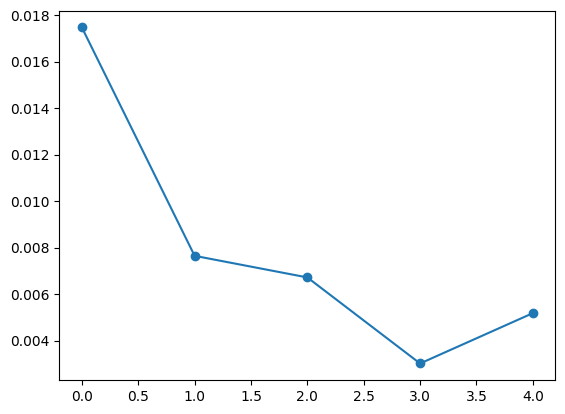

In [34]:
plt.plot([-i for i in pens_real], marker='o')
plt.plot([-i for i in pens_naive], marker='x')
plt.plot([-i for i in pens_flow], marker='^')

In [35]:
pens_naive

[[-0.022618797, -0.009621052, -0.005629682, -0.0071115308, -0.0055548158],
 [-0.016284581, -0.012329822, -0.009788437, -0.0068809153, -0.005305318],
 [-0.021682328, -0.0140212495, -0.00814831, -0.006365585, -0.0066172937],
 [-0.014867574, -0.013384566, -0.009827407, -0.0041557197, -0.0052101803],
 [-0.0148130525, -0.011421999, -0.008909913, -0.0067135124, -0.00541347]]

In [37]:
pens_flow

[[-0.017185327, -0.013823095, -0.00749482, -0.005293492, -0.0049088523],
 [-0.015650708, -0.012117149, -0.010009443, -0.0053155744, -0.0045788293],
 [-0.01591008, -0.010292262, -0.008131781, -0.004652883, -0.0060133548],
 [-0.014638695, -0.009541137, -0.0067807226, -0.005221254, -0.0048238216],
 [-0.013783252, -0.00921412, -0.007816711, -0.0049440865, -0.00974809]]

In [38]:
pens_real

[-0.01747567, -0.007646727, -0.006716923, -0.0030134046, -0.0051793]